In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [2]:
# Load dataset
print('Olamilekan Elegbede')
df = pd.read_csv('Forbes-list-2020.csv')
df.head()

Olamilekan Elegbede


,Name,NetWorth in billions,Country,Source,Rank,Age,Industry
0,Jeff Bezos,177.0,United States,Amazon,1,57,Technology
1,Elon Musk,151.0,United States,"Tesla, SpaceX",2,49,Automotive
2,Bernard Arnault & family,150.0,France,LVMH,3,72,Fashion & Retail
3,Bill Gates,124.0,United States,Microsoft,4,65,Technology
4,Mark Zuckerberg,97.0,United States,Facebook,5,36,Technology


### Q1: Univariate Analysis
Compute summary statistics (mean, median, min, max, std) for `NetWorth` and `Age`. Identify the youngest and oldest billionaires.

In [3]:
print('Olamilekan Elegbede')
df.describe()

Olamilekan Elegbede


,NetWorth in billions,Rank,Age
count,2755.000000,2755.000000,2755.000000
mean,4.749220,1345.663521,63.014519
std,9.615358,772.669811,13.259017
min,1.000000,1.000000,18.000000
25%,1.500000,680.000000,54.000000
50%,2.300000,1362.000000,62.000000
75%,4.200000,2035.000000,72.000000
max,177.000000,2674.000000,97.000000


### Q2: Bivariate Analysis (Categorical vs Numerical)
Compare the average `NetWorth` across different `Industries`. Which industry has the highest average net worth?

In [4]:
print('Olamilekan Elegbede')
# Group by industry
df['NetWorth in billions'].groupby(df['Industry']).mean()

Olamilekan Elegbede


Industry
Automotive                    6.875000
Construction & Engineering    2.843182
Diversified                   4.617553
Energy                        4.526000
Fashion & Retail              6.218315
Finance & Investments         4.118329
Food & Beverage               4.702740
Gambling & Casinos            5.360000
Healthcare                    3.577828
Logistics                     4.165714
Manufacturing                 3.383384
Media & Entertainment         5.066316
Metals & Mining               5.829730
Real Estate                   3.794419
Service                       3.316000
Sports                        3.404167
Technology                    6.730685
Telecom                       6.543750
Name: NetWorth in billions, dtype: float64

### Q3: Bivariate Analysis (Numerical vs Numerical)
Explore the relationship between `Age` and `NetWorth` using a scatterplot. Do younger billionaires tend to have higher net worth than older ones?

Olamilekan Elegbede


Text(0, 0.5, 'NetWorth in billions')

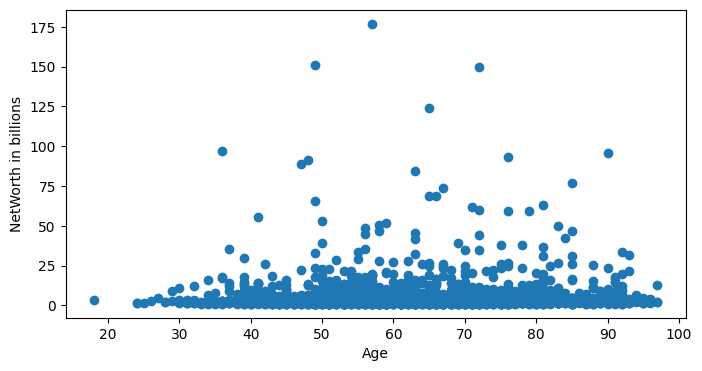

In [5]:
print('Olamilekan Elegbede')
import matplotlib.pyplot as plt

# Use Scatter plot with pandas
fig, axes = plt.subplots(figsize=(8,4))

axes.scatter(df['Age'], df['NetWorth in billions'])
axes.set_xlabel('Age')
axes.set_ylabel('NetWorth in billions')


### Q4: Country Profile
Which Country has the highest number of billionaires in the Technology industry using crosstab?

In [6]:
print('Olamilekan Elegbede')

# filter for technology industry
a = df[df['Industry']=='Technology']

pd.crosstab(a['Country'],a['Industry'])

Olamilekan Elegbede


Industry,Technology
Country,
Argentina,1
Australia,3
Brazil,4
Canada,10
China,111
Czechia,2
France,1
Germany,15
Hong Kong,4


United States has the highest number of billionaries in Technology at - 140

### Q5: Standardization using Z-score
Identify outliers based on Networth (z-score > 2 or < -2).

In [7]:
print('Olamilekan Elegbede')

scaler = StandardScaler()

# fit and transform the Networth
df['Networth_z'] = scaler.fit_transform(df[['NetWorth in billions']])

Olamilekan Elegbede


In [8]:
# identify the outliers (z-score > 2 or < -2)
df[(df['Networth_z'] < -2) | (df['Networth_z'] > 2)]

,Name,NetWorth in billions,Country,Source,Rank,Age,Industry,Networth_z
0,Jeff Bezos,177.0,United States,Amazon,1,57,Technology,17.917382
1,Elon Musk,151.0,United States,"Tesla, SpaceX",2,49,Automotive,15.212884
2,Bernard Arnault & family,150.0,France,LVMH,3,72,Fashion & Retail,15.108865
3,Bill Gates,124.0,United States,Microsoft,4,65,Technology,12.404367
4,Mark Zuckerberg,97.0,United States,Facebook,5,36,Technology,9.595849
...,...,...,...,...,...,...,...,...
64,Thomas Peterffy,25.0,United States,discount brokerage,65,76,Finance & Investments,2.106469
65,Vagit Alekperov,24.9,Russia,oil,66,70,Energy,2.096067
66,Leonid Mikhelson,24.9,Russia,"gas, chemicals",66,65,Energy,2.096067
67,Jim Simons,24.6,United States,hedge funds,68,82,Finance & Investments,2.064862


### Q6: Normalization
Normalize the `NetWorth` column to a 0-1 scale using min-max normalization.

In [9]:
print('Olamilekan Elegbede')

minmax = MinMaxScaler(feature_range=(0,1))

df['Networth_mm'] = minmax.fit_transform(df[['NetWorth in billions']])
df.head()

Olamilekan Elegbede


,Name,NetWorth in billions,Country,Source,Rank,Age,Industry,Networth_z,Networth_mm
0,Jeff Bezos,177.0,United States,Amazon,1,57,Technology,17.917382,1.000000
1,Elon Musk,151.0,United States,"Tesla, SpaceX",2,49,Automotive,15.212884,0.852273
2,Bernard Arnault & family,150.0,France,LVMH,3,72,Fashion & Retail,15.108865,0.846591
3,Bill Gates,124.0,United States,Microsoft,4,65,Technology,12.404367,0.698864
4,Mark Zuckerberg,97.0,United States,Facebook,5,36,Technology,9.595849,0.545455


### Q7: Correlation and Covariance
Compute correlation and covariance between `Age` and `NetWorth`. What does the result suggest?

In [10]:
print('Olamilekan Elegbede \n')

corr = df.select_dtypes(include='number').corr()

print('Correlation between Age and Networth (B):')
df['Age'].corr(df['NetWorth in billions'])


Olamilekan Elegbede 

Correlation between Age and Networth (B):


0.03522514709484203

In [11]:
# coveriance
df['Age'].cov(df['NetWorth in billions'])

4.490861007977837

These suggests there's no relationship between the two features and near zero correlation/weak correlation.